In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scienceplots

from scipy.signal import savgol_filter

plt.style.use(["science","bright","grid"])

In [2]:
AMPLITUDE_LIST  = [0.07, 0.14, 0.21, 0.28, 0.35]
BETA_LIST       = [0.05, 0.1, 0.5, 1.0, 3.0, 10.0, 50.0]
PATH            = "../../data/raw/dynamic_resistances/sweep_amp_beta/"
data = {}

for amp in AMPLITUDE_LIST:
    data[amp] = {}
    for beta in BETA_LIST:
        df  = pd.read_csv(f"{PATH}Nx=9_Ny=9_Ne=2_amp{amp:.3f}_beta{beta:.2f}.csv")
        df  = df.drop(columns=['E1','G','Eq_Jumps','Jumps'])
        
        df['Total'] = df['Observable'] + df['Displacement']
        df['Resistance'] = pd.read_parquet(f"{PATH}resistances_Nx=9_Ny=9_Ne=2_amp{amp:.3f}_beta{beta:.2f}.parquet").mean(axis=1).values
        
        data[amp][beta] = df

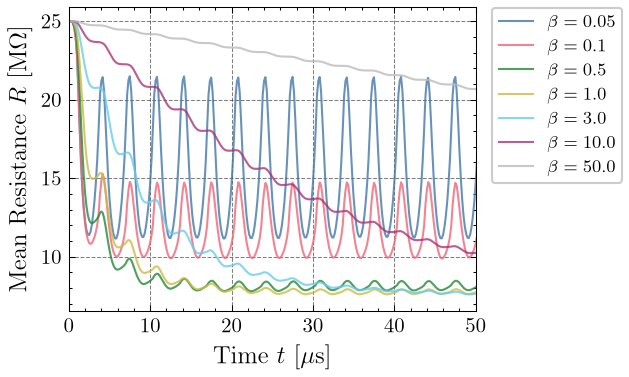

In [3]:
target_amp = 0.35
fig, ax = plt.subplots(dpi=150)

for beta in BETA_LIST:
    df = data[target_amp][beta]
    time_us = df['t'].values * 1e9  
    ax.plot(time_us, df['Resistance'].values, label=rf"$\beta = {beta}$", alpha=0.8)

_ = ax.set_xlabel(r"Time $t$ [$\mu$s]", size="large")
_ = ax.set_ylabel(r"Mean Resistance $R$ [M$\Omega$]", size="large")
_ = ax.set_xlim(0,50)
_ = ax.legend(frameon=True, bbox_to_anchor=(1.2,0.71), loc='center', fontsize='small')

In [4]:
V_smooth = savgol_filter(df['E0'].values, 11, 3)
I_smooth = savgol_filter(df['Total'].values, 15, 3)

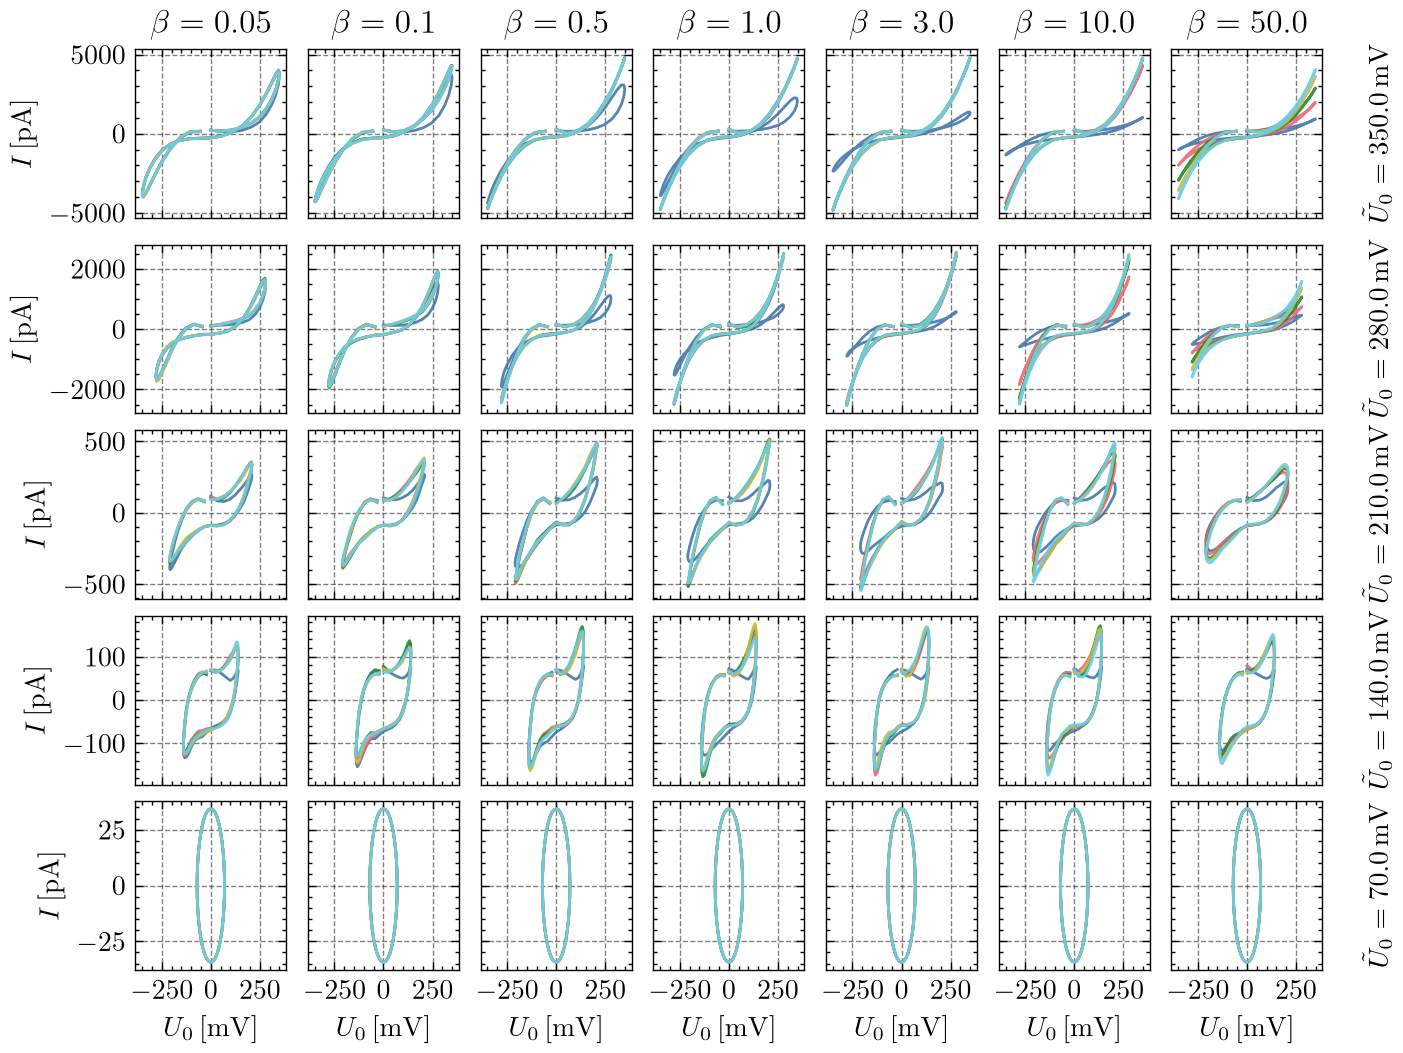

In [23]:
steps_per_period = 40

fig, axes = plt.subplots(
    len(AMPLITUDE_LIST), len(BETA_LIST),
    dpi=200, sharex=True, sharey='row', layout='constrained'
)

fig.set_figwidth(fig.get_figwidth() * 2)
fig.set_figheight(fig.get_figheight() * 2)

for i, amp in enumerate(reversed(AMPLITUDE_LIST)):
    for j, beta in enumerate(BETA_LIST):
        ax = axes[i, j]
        df = data[amp][beta]

        for n in [0, 8, 16, 24, 32]:
            V_last = savgol_filter(
                df['E0'].values[n*steps_per_period:(n+1)*steps_per_period] * 1000,
                11, 3
            )
            I_last = savgol_filter(
                df['Total'].values[n*steps_per_period:(n+1)*steps_per_period] * 1e-6,
                11, 3
            )
            ax.plot(V_last, I_last, alpha=0.9)

        if i == 0:
            ax.set_title(f"$\\beta = {beta}$")

        if i == len(AMPLITUDE_LIST) - 1:
            ax.set_xlabel(r"$U_0\,[\mathrm{mV}]$")

        # Regular y-axis label on the left
        if j == 0:
            ax.set_ylabel(r"$I\,[\mathrm{pA}]$")

        # Amplitude label on the right of the row
        if j == len(BETA_LIST) - 1:
            ax.yaxis.set_label_position("right")
            ax.set_ylabel(
                rf"$\tilde{{U}}_0 = {amp*1000}\,\mathrm{{mV}}$",
                rotation=90,
                labelpad=20,
                va="center"
            )

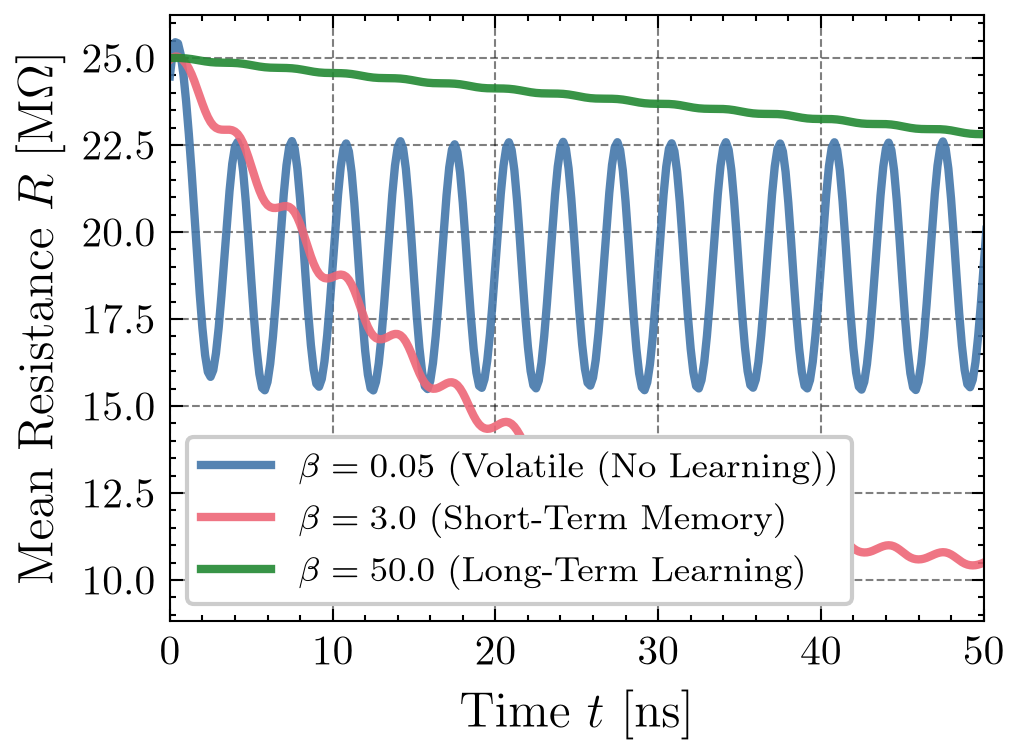

In [9]:
fig, ax = plt.subplots(dpi=300)

target_amp = 0.28 
plot_betas = [0.05, 3.0, 50.0]
labels = ["Volatile (No Learning)", "Short-Term Memory", "Long-Term Learning"]

for beta, label in zip(plot_betas, labels):
    df = data[target_amp][beta]
    time_us = df['t'].values * 1e9
    
    # 1. Glätten des Widerstands (Window=15, Polynom=3)
    R_smooth = savgol_filter(df['Resistance'].values, window_length=15, polyorder=3)
    
    ax.plot(time_us, R_smooth, label=f"$\\beta = {beta}$ ({label})", lw=2, alpha=0.9)

_ = ax.set_xlabel(r"Time $t$ [ns]", size="large")
_ = ax.set_ylabel(r"Mean Resistance $R$ [M$\Omega$]", size="large")
_ = ax.set_xlim(0,50)
_ = ax.legend(frameon=True, loc='lower left', fontsize='small')

<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_13183/2883246528.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax.set_xlabel(f"$U_0~[\mathrm{{mV}}]$")
/tmp/ipykernel_13183/2883246528.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax.set_ylabel(f"$I~[\mathrm{{pA}}]$")


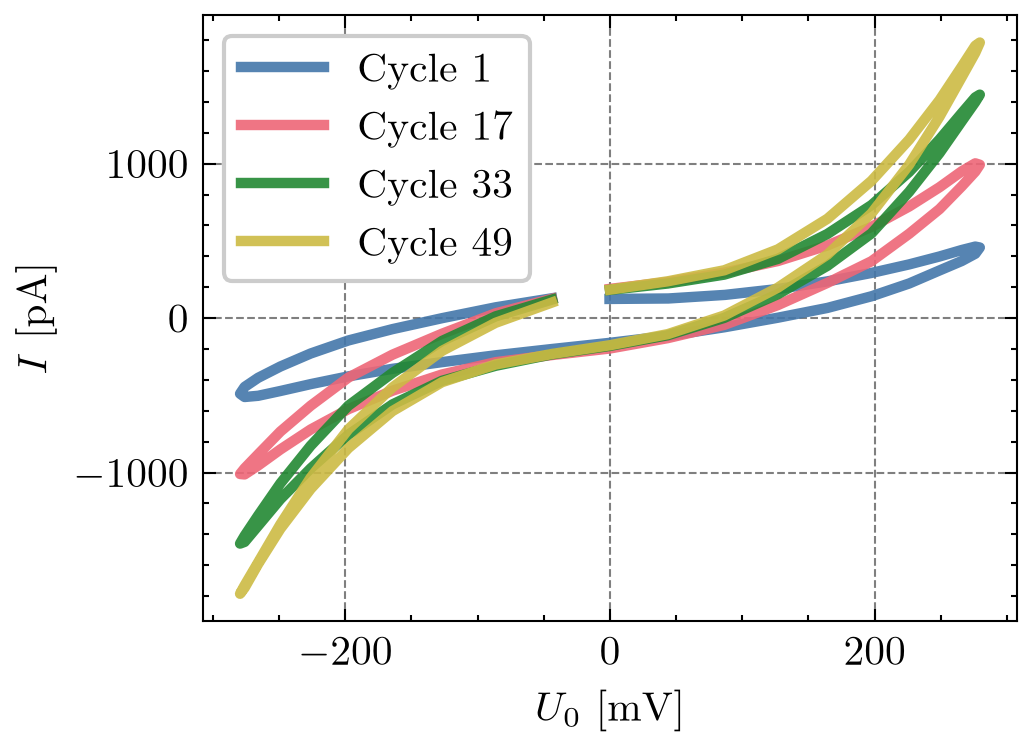

In [29]:
fig, ax = plt.subplots(dpi=300)

target_amp = 0.28
target_beta = 50.0
df = data[target_amp][target_beta]

V_smooth = savgol_filter(df['E0'].values, 11, 3)*1000
I_smooth = savgol_filter(df['Total'].values, 15, 3)*1e-6

steps_per_period = 40
periods_to_plot = [0, 16, 32, 48] 

for idx, p in enumerate(periods_to_plot):
    start = p * steps_per_period
    end = (p + 1) * steps_per_period
    
    ax.plot(V_smooth[start:end], I_smooth[start:end], 
            lw=2.5, alpha=0.9, label=f"Cycle {p+1}")

ax.set_xlabel(f"$U_0~[\mathrm{{mV}}]$")
ax.set_ylabel(f"$I~[\mathrm{{pA}}]$")
ax.legend(frameon=True, loc="upper left")